In [1]:
import os
import pandas as pd
from glob import glob

ROOT = r"D:\TACE"

PRE_DIR  = os.path.join(ROOT, "PRE")
POST_DIR = os.path.join(ROOT, "POST")
MASK_DIR = os.path.join(ROOT, "MASK")


def build_dataset_index(pre_dir, post_dir, mask_dir):
    dataset = []

    patient_ids = sorted(os.listdir(pre_dir))

    for pid in patient_ids:
        pre_path  = os.path.join(pre_dir, pid)
        post_path = os.path.join(post_dir, pid)
        mask_path = os.path.join(mask_dir, pid)

        dataset.append({
            "patient_id": pid,
            "pre_dicom_paths": sorted(glob(os.path.join(pre_path, "*.dcm"))),
            "post_dicom_paths": sorted(glob(os.path.join(post_path, "*.dcm"))),
            "mask_dicom_paths": sorted(glob(os.path.join(mask_path, "*.dcm")))
        })

    return pd.DataFrame(dataset)


dataset_df = build_dataset_index(PRE_DIR, POST_DIR, MASK_DIR)
dataset_df.head()

,patient_id,pre_dicom_paths,post_dicom_paths,mask_dicom_paths
0,1,"[D:\TACE\PRE\1\1-01.dcm, D:\TACE\PRE\1\1-02.dc...","[D:\TACE\POST\1\1-01.dcm, D:\TACE\POST\1\1-02....",[D:\TACE\MASK\1\1-1.dcm]
1,10,"[D:\TACE\PRE\10\1-001.dcm, D:\TACE\PRE\10\1-00...","[D:\TACE\POST\10\1-01.dcm, D:\TACE\POST\10\1-0...",[D:\TACE\MASK\10\1-1.dcm]
2,100,"[D:\TACE\PRE\100\1-001.dcm, D:\TACE\PRE\100\1-...","[D:\TACE\POST\100\1-001.dcm, D:\TACE\POST\100\...",[D:\TACE\MASK\100\1-1.dcm]
3,101,"[D:\TACE\PRE\101\1-001.dcm, D:\TACE\PRE\101\1-...","[D:\TACE\POST\101\1-001.dcm, D:\TACE\POST\101\...",[D:\TACE\MASK\101\1-1.dcm]
4,102,"[D:\TACE\PRE\102\1-001.dcm, D:\TACE\PRE\102\1-...","[D:\TACE\POST\102\1-001.dcm, D:\TACE\POST\102\...",[D:\TACE\MASK\102\1-1.dcm]


In [2]:
pip install highdicom

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pydicom
import nibabel as nib
import highdicom as hd
from glob import glob
from tqdm import tqdm


In [4]:
import numpy as np
import pydicom

def load_ct_series(dicom_paths):
    slices = [pydicom.dcmread(p) for p in dicom_paths]

    # Sort by Z position
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    volume = np.stack([s.pixel_array for s in slices], axis=0).astype(np.float32)

    # In-plane spacing
    dx, dy = map(float, slices[0].PixelSpacing)

    # Robust Z-spacing
    z_positions = [float(s.ImagePositionPatient[2]) for s in slices]
    z_diffs = np.diff(sorted(z_positions))

    if len(z_diffs) > 0 and np.all(z_diffs > 0):
        dz = float(np.median(z_diffs))
    else:
        dz = float(getattr(slices[0], "SliceThickness", 1.0))
        if dz == 0:
            dz = 1.0  # SAFE FALLBACK

    spacing = (dz, dx, dy)

    print(f"✅ CT Loaded: {volume.shape} | Spacing: {spacing}")
    return volume, slices, spacing

def inspect_segments(seg_ds):
    labels = [s.SegmentLabel for s in seg_ds.SegmentSequence]
    pixel_array = seg_ds.pixel_array
    frames = seg_ds.PerFrameFunctionalGroupsSequence

    voxel_counts = {lbl: 0 for lbl in labels}
    for i in range(pixel_array.shape[0]):
        seg_num = frames[i].SegmentIdentificationSequence[0].ReferencedSegmentNumber
        voxel_counts[labels[seg_num - 1]] += np.sum(pixel_array[i] > 0)

    print("🧠 Available segments:")
    for k, v in voxel_counts.items():
        print(f"  • {k:<18}: {v} voxels")
    return labels
def align_segmentation_to_ct(seg_ds, ct_slices, target_label):
    labels = [s.SegmentLabel for s in seg_ds.SegmentSequence]
    target_index = labels.index(target_label) + 1

    pixel_array = seg_ds.pixel_array
    frames = seg_ds.PerFrameFunctionalGroupsSequence

    ct_z = np.array([float(s.ImagePositionPatient[2]) for s in ct_slices])
    aligned_mask = np.zeros((len(ct_z), *pixel_array.shape[1:]), dtype=np.uint8)

    for i in tqdm(range(pixel_array.shape[0]), desc=f"Aligning {target_label}"):
        seg_id = frames[i].SegmentIdentificationSequence[0].ReferencedSegmentNumber
        if seg_id != target_index:
            continue

        z_seg = float(frames[i].PlanePositionSequence[0].ImagePositionPatient[2])
        z_idx = np.argmin(np.abs(ct_z - z_seg))
        aligned_mask[z_idx] = np.maximum(aligned_mask[z_idx], pixel_array[i])

    print(f"✅ {target_label} aligned | Shape: {aligned_mask.shape} | Voxels: {np.sum(aligned_mask)}")
    return aligned_mask

def save_nifti(volume, spacing, path):
    affine = np.diag([spacing[2], spacing[1], spacing[0], 1])
    nib.save(nib.Nifti1Image(volume.astype(np.float32), affine), path)



In [5]:
import os
import pydicom
import numpy as np
from tqdm import tqdm

OUTPUT_DIR = "/kaggle/working/processed/pre"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Saving outputs to: {OUTPUT_DIR}")
print(f"👥 Total patients: {len(dataset_df)}")

# ===============================
# Batch loop over all patients
# ===============================
for idx, row in tqdm(dataset_df.iterrows(),
                     total=len(dataset_df),
                     desc="Processing patients"):

    pid = row.patient_id
    print(f"\n🚀 Processing Patient {pid}")

    try:
        # --------------------------------------------------
        # 1. Load PRE-TACE CT
        # --------------------------------------------------
        pre_ct, ref_slices, spacing = load_ct_series(row.pre_dicom_paths)

        # Save PRE CT
        save_nifti(
            pre_ct,
            spacing,
            f"{OUTPUT_DIR}/{pid}_pre_ct.nii.gz"
        )

        # --------------------------------------------------
        # 2. Load DICOM Segmentation
        # --------------------------------------------------
        seg_path = row.mask_dicom_paths[0]
        seg_ds = pydicom.dcmread(seg_path)

        # Inspect available segments
        segment_labels = inspect_segments(seg_ds)

        # --------------------------------------------------
        # 3. Extract & align each segment
        # --------------------------------------------------
        for label in segment_labels:
            try:
                mask = align_segmentation_to_ct(
                    seg_ds,
                    ref_slices,
                    label
                )

                save_nifti(
                    mask,
                    spacing,
                    f"{OUTPUT_DIR}/{pid}_{label.replace(' ', '_')}.nii.gz"
                )

            except Exception as e:
                print(f"⚠️  Patient {pid} | Segment '{label}' failed: {e}")

        print(f"✅ Patient {pid} completed")

    except Exception as e:
        print(f"❌ Patient {pid} FAILED: {e}")
        continue

print("\n🎉 STEP-2 BATCH PROCESSING COMPLETE")


📁 Saving outputs to: /kaggle/working/processed/pre
👥 Total patients: 105


Processing patients:   0%|          | 0/105 [00:00<?, ?it/s]


🚀 Processing Patient 1
✅ CT Loaded: (43, 512, 512) | Spacing: (5.0, 0.78125, 0.78125)
🧠 Available segments:
  • Liver             : 481874 voxels
  • Mass              : 11715 voxels
  • Portal vein       : 7736 voxels
  • Abdominal aorta   : 5529 voxels


Aligning Liver: 100%|██████████| 148/148 [00:00<00:00, 11292.24it/s]

✅ Liver aligned | Shape: (43, 512, 512) | Voxels: 481874


...

✅ Portal vein aligned | Shape: (218, 512, 512) | Voxels: 137048


Aligning Abdominal aorta: 100%|██████████| 436/436 [00:00<00:00, 12294.80it/s]


✅ Abdominal aorta aligned | Shape: (218, 512, 512) | Voxels: 7149


Processing patients: 100%|██████████| 105/105 [23:37<00:00, 13.50s/it]

✅ Patient 99 completed

🎉 STEP-2 BATCH PROCESSING COMPLETE


In [ ]:
import os
from tqdm import tqdm

# ===============================
# LOCAL OUTPUT DIR
# ===============================
OUTPUT_DIR = r"D:\TACE\processed\post"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Saving POST-TACE CT volumes to: {OUTPUT_DIR}")
print(f"👥 Total patients: {len(dataset_df)}")

# =========================================
# Batch loop for saving POST-TACE CT volumes
# =========================================
for idx, row in tqdm(
    dataset_df.iterrows(),
    total=len(dataset_df),
    desc="Saving POST-TACE CT"
):

    pid = str(row.patient_id)
    print(f"\n🚀 Processing Patient {pid}")

    try:
        # -------------------------------------
        # Check if POST exists
        # -------------------------------------
        if len(row.post_dicom_paths) == 0:
            raise ValueError("No POST DICOM files found")

        # -------------------------------------
        # Load POST-TACE CT
        # -------------------------------------
        post_ct_vol, _, post_spacing = load_ct_series(row.post_dicom_paths)

        # -------------------------------------
        # Save as NIfTI
        # -------------------------------------
        save_nifti(
            post_ct_vol,
            post_spacing,
            os.path.join(OUTPUT_DIR, f"{pid}_post_ct.nii.gz")
        )

        print(f"✅ Patient {pid}: POST-TACE CT saved")

    except Exception as e:
        print(f"❌ Patient {pid}: Failed → {e}")
        continue

print("\n🎉 STEP-2.5 COMPLETE: All POST-TACE CT volumes processed")

📁 Saving POST-TACE CT volumes to: D:\TACE\processed
👥 Total patients: 105


Saving POST-TACE CT:   0%|          | 0/105 [00:00<?, ?it/s]


🚀 Processing Patient 1
✅ CT Loaded: (92, 512, 512) | Spacing: (2.5, 0.78125, 0.78125)


Saving POST-TACE CT:   1%|          | 1/105 [00:04<07:08,  4.12s/it]

✅ Patient 1: POST-TACE CT saved

🚀 Processing Patient 10
✅ CT Loaded: (85, 512, 512) | Spacing: (2.5, 0.703125, 0.703125)


...

✅ Patient 97: POST-TACE CT saved

🚀 Processing Patient 98
✅ CT Loaded: (186, 512, 512) | Spacing: (2.5, 0.664062, 0.664062)


Saving POST-TACE CT:  99%|█████████▉| 104/105 [08:57<00:06,  6.54s/it]

✅ Patient 98: POST-TACE CT saved

🚀 Processing Patient 99
✅ CT Loaded: (185, 512, 512) | Spacing: (2.5, 0.742188, 0.742188)


Saving POST-TACE CT: 100%|██████████| 105/105 [09:04<00:00,  5.18s/it]

✅ Patient 99: POST-TACE CT saved

🎉 STEP-2.5 COMPLETE: All POST-TACE CT volumes processed


In [12]:
import os

# ===============================
# CORRECT BASE DIR
# ===============================
BASE_DIR = r"D:\TACE\processed"

PRE_DIR  = os.path.join(BASE_DIR, "pre")
POST_DIR = os.path.join(BASE_DIR, "post")

missing = []

print("🔍 Checking PRE and POST CT files for all patients\n")

for _, row in dataset_df.iterrows():
    pid = str(row.patient_id)

    pre_path  = os.path.join(PRE_DIR,  f"{pid}_pre_ct.nii.gz")
    post_path = os.path.join(POST_DIR, f"{pid}_post_ct.nii.gz")

    pre_ok  = os.path.exists(pre_path)
    post_ok = os.path.exists(post_path)

    print(
        f"Patient {pid:>3} | "
        f"PRE: {'FOUND' if pre_ok else 'MISSING'} | "
        f"POST: {'FOUND' if post_ok else 'MISSING'}"
    )

    if not (pre_ok and post_ok):
        missing.append(pid)

print("\n==============================")

if len(missing) == 0:
    print("✅ ALL patients have both PRE and POST CT volumes")
else:
    print(f"❌ Missing files for patients: {missing}")

🔍 Checking PRE and POST CT files for all patients

Patient   1 | PRE: FOUND | POST: FOUND
Patient  10 | PRE: FOUND | POST: FOUND
Patient 100 | PRE: FOUND | POST: FOUND
Patient 101 | PRE: FOUND | POST: FOUND
Patient 102 | PRE: FOUND | POST: FOUND
Patient 103 | PRE: FOUND | POST: FOUND
Patient 104 | PRE: FOUND | POST: FOUND
Patient 105 | PRE: FOUND | POST: FOUND
Patient  11 | PRE: FOUND | POST: FOUND
Patient  12 | PRE: FOUND | POST: FOUND
Patient  13 | PRE: FOUND | POST: FOUND
Patient  14 | PRE: FOUND | POST: FOUND
Patient  15 | PRE: FOUND | POST: FOUND
Patient  16 | PRE: FOUND | POST: FOUND
Patient  17 | PRE: FOUND | POST: FOUND
Patient  18 | PRE: FOUND | POST: FOUND
Patient  19 | PRE: FOUND | POST: FOUND
Patient   2 | PRE: FOUND | POST: FOUND
Patient  20 | PRE: FOUND | POST: FOUND
Patient  21 | PRE: FOUND | POST: FOUND
Patient  22 | PRE: FOUND | POST: FOUND
Patient  23 | PRE: FOUND | POST: FOUND
Patient  24 | PRE: FOUND | POST: FOUND
Patient  25 | PRE: FOUND | POST: FOUND
Patient  26 |

In [13]:
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import distance_transform_edt


In [15]:
import os
import nibabel as nib

# ===============================
# BASE + SUBFOLDERS
# ===============================
BASE = r"D:\TACE\processed"

PRE_DIR  = os.path.join(BASE, "pre")
POST_DIR = os.path.join(BASE, "post")

print("🔍 Loading PRE/POST CT and masks for all patients\n")

for _, row in dataset_df.iterrows():
    pid = str(row.patient_id)

    try:
        # -------------------------
        # Build correct paths
        # -------------------------
        pre_path    = os.path.join(PRE_DIR,  f"{pid}_pre_ct.nii.gz")
        post_path   = os.path.join(POST_DIR, f"{pid}_post_ct.nii.gz")

        # Masks (still in BASE)
        liver_path  = os.path.join(PRE_DIR, f"{pid}_Liver.nii.gz")
        tumor_path  = os.path.join(PRE_DIR, f"{pid}_Mass.nii.gz")
        portal_path = os.path.join(PRE_DIR, f"{pid}_Portal_vein.nii.gz")
        aorta_path  = os.path.join(PRE_DIR, f"{pid}_Abdominal_aorta.nii.gz")

        # -------------------------
        # Check files exist (IMPORTANT)
        # -------------------------
        for p in [pre_path, post_path, liver_path, tumor_path, portal_path, aorta_path]:
            if not os.path.exists(p):
                raise FileNotFoundError(f"Missing: {p}")

        # -------------------------
        # Load volumes
        # -------------------------
        pre_ct  = nib.load(pre_path).get_fdata()
        post_ct = nib.load(post_path).get_fdata()

        liver  = nib.load(liver_path).get_fdata()
        tumor  = nib.load(tumor_path).get_fdata()
        portal = nib.load(portal_path).get_fdata()
        aorta  = nib.load(aorta_path).get_fdata()

        print(
            f"Patient {pid:>3} | "
            f"PRE CT: {pre_ct.shape} | "
            f"POST CT: {post_ct.shape} | "
            f"Liver: {liver.shape} | "
            f"Tumor: {tumor.shape}"
        )

        # -------------------------
        # Consistency check (PRE space)
        # -------------------------
        assert pre_ct.shape == liver.shape == tumor.shape == portal.shape == aorta.shape

    except Exception as e:
        print(f"❌ Patient {pid}: Failed → {e}")

print("\n✅ Batch loading check complete")

🔍 Loading PRE/POST CT and masks for all patients

Patient   1 | PRE CT: (43, 512, 512) | POST CT: (92, 512, 512) | Liver: (43, 512, 512) | Tumor: (43, 512, 512)
Patient  10 | PRE CT: (172, 512, 512) | POST CT: (85, 512, 512) | Liver: (172, 512, 512) | Tumor: (172, 512, 512)
Patient 100 | PRE CT: (262, 512, 512) | POST CT: (236, 512, 512) | Liver: (262, 512, 512) | Tumor: (262, 512, 512)
Patient 101 | PRE CT: (182, 512, 512) | POST CT: (222, 512, 512) | Liver: (182, 512, 512) | Tumor: (182, 512, 512)
Patient 102 | PRE CT: (176, 512, 512) | POST CT: (196, 512, 512) | Liver: (176, 512, 512) | Tumor: (176, 512, 512)
Patient 103 | PRE CT: (180, 512, 512) | POST CT: (158, 512, 512) | Liver: (180, 512, 512) | Tumor: (180, 512, 512)
Patient 104 | PRE CT: (198, 512, 512) | POST CT: (184, 512, 512) | Liver: (198, 512, 512) | Tumor: (198, 512, 512)
Patient 105 | PRE CT: (162, 512, 512) | POST CT: (166, 512, 512) | Liver: (162, 512, 512) | Tumor: (162, 512, 512)
Patient  11 | PRE CT: (245, 512, 51

In [16]:
assert pre_ct.shape == tumor.shape == liver.shape, "PRE CT and masks mismatch"
assert portal.shape == pre_ct.shape, "Portal vein mismatch"
assert aorta.shape == pre_ct.shape, "Aorta mismatch"

print("✅ PRE space sanity check passed")


✅ PRE space sanity check passed


In [17]:
def normalize_ct(vol):
    p1, p99 = np.percentile(vol, [1, 99])
    vol = np.clip(vol, p1, p99)
    return (vol - vol.min()) / (vol.max() - vol.min())
def region_stats(ct, mask):
    idx = mask > 0
    if np.sum(idx) == 0:
        return {
            "mean": 0,
            "std": 0,
            "min": 0,
            "max": 0,
            "volume": 0
        }

    vals = ct[idx]
    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "volume": int(np.sum(idx))
    }

features = {}

# Tumor PRE
tumor_pre = region_stats(pre_ct, tumor)
features.update({
    "tumor_pre_mean": tumor_pre["mean"],
    "tumor_pre_std": tumor_pre["std"],
    "tumor_pre_volume": tumor_pre["volume"]
})

# Liver PRE
liver_pre = region_stats(pre_ct, liver)
features.update({
    "liver_pre_mean": liver_pre["mean"],
    "liver_pre_std": liver_pre["std"]
})

# Vessel PRE
portal_pre = region_stats(pre_ct, portal)
aorta_pre  = region_stats(pre_ct, aorta)

features.update({
    "portal_pre_mean": portal_pre["mean"],
    "portal_pre_volume": portal_pre["volume"],
    "aorta_pre_mean": aorta_pre["mean"]
})

def min_distance(mask_a, mask_b):
    if np.sum(mask_a) == 0 or np.sum(mask_b) == 0:
        return np.inf
    dist_map = distance_transform_edt(mask_b == 0)
    return float(np.min(dist_map[mask_a > 0]))

features["tumor_to_portal_dist"] = min_distance(tumor, portal)
features["tumor_to_aorta_dist"]  = min_distance(tumor, aorta)


coords = np.where(tumor > 0)
zmin, zmax = coords[0].min(), coords[0].max()
ymin, ymax = coords[1].min(), coords[1].max()
xmin, xmax = coords[2].min(), coords[2].max()

margin = 10
zmin = max(0, zmin - margin)
ymin = max(0, ymin - margin)
xmin = max(0, xmin - margin)

zmax = min(pre_ct.shape[0], zmax + margin)
ymax = min(pre_ct.shape[1], ymax + margin)
xmax = min(pre_ct.shape[2], xmax + margin)


z_len = zmax - zmin
z_center = post_ct.shape[0] // 2

post_crop = post_ct[
    z_center - z_len//2 : z_center + z_len//2,
    ymin:ymax,
    xmin:xmax
]

post_vals = post_crop.flatten()

features.update({
    "tumor_post_mean": float(np.mean(post_vals)),
    "tumor_post_std": float(np.std(post_vals)),
    "tumor_post_min": float(np.min(post_vals)),
    "tumor_post_max": float(np.max(post_vals))
})

features["delta_tumor_mean"] = (
    features["tumor_post_mean"] - features["tumor_pre_mean"]
)

features["delta_tumor_std"] = (
    features["tumor_post_std"] - features["tumor_pre_std"]
)



In [19]:
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import distance_transform_edt
from tqdm import tqdm
import os

# ===============================
# PATHS (FIXED)
# ===============================
BASE = r"D:\TACE\processed"
PRE_DIR  = os.path.join(BASE, "pre")
POST_DIR = os.path.join(BASE, "post")

# -----------------------------
# Helper functions
# -----------------------------
def region_stats(ct, mask):
    idx = mask > 0
    if np.sum(idx) == 0:
        return dict(mean=0, std=0, min=0, max=0, volume=0)

    vals = ct[idx]
    return dict(
        mean=float(np.mean(vals)),
        std=float(np.std(vals)),
        min=float(np.min(vals)),
        max=float(np.max(vals)),
        volume=int(np.sum(idx))
    )

def min_distance(mask_a, mask_b):
    if np.sum(mask_a) == 0 or np.sum(mask_b) == 0:
        return np.nan
    dist_map = distance_transform_edt(mask_b == 0)
    return float(np.min(dist_map[mask_a > 0]))

# -----------------------------
# Batch feature extraction
# -----------------------------
all_features = []

print("🚀 Extracting features for all patients\n")

for _, row in tqdm(dataset_df.iterrows(),
                   total=len(dataset_df),
                   desc="Feature Extraction"):

    pid = str(row.patient_id)

    try:
        # -----------------------------
        # Correct paths (Pointed to PRE_DIR)
        # -----------------------------
        pre_path    = os.path.join(PRE_DIR,  f"{pid}_pre_ct.nii.gz")
        post_path   = os.path.join(POST_DIR, f"{pid}_post_ct.nii.gz")

        # CHANGED: These now look in PRE_DIR instead of BASE
        liver_path  = os.path.join(PRE_DIR, f"{pid}_Liver.nii.gz")
        tumor_path  = os.path.join(PRE_DIR, f"{pid}_Mass.nii.gz")
        portal_path = os.path.join(PRE_DIR, f"{pid}_Portal_vein.nii.gz")
        aorta_path  = os.path.join(PRE_DIR, f"{pid}_Abdominal_aorta.nii.gz")
        

        # -----------------------------
        # Check existence
        # -----------------------------
        for p in [pre_path, post_path, liver_path, tumor_path, portal_path, aorta_path]:
            if not os.path.exists(p):
                raise FileNotFoundError(f"Missing file: {p}")

        # -----------------------------
        # Load data
        # -----------------------------
        pre_ct  = nib.load(pre_path).get_fdata()
        post_ct = nib.load(post_path).get_fdata()

        liver  = nib.load(liver_path).get_fdata()
        tumor  = nib.load(tumor_path).get_fdata()
        portal = nib.load(portal_path).get_fdata()
        aorta  = nib.load(aorta_path).get_fdata()

        # -----------------------------
        # Ensure masks are boolean (IMPORTANT FIX)
        # -----------------------------
        liver  = liver > 0
        tumor  = tumor > 0
        portal = portal > 0
        aorta  = aorta > 0

        features = {}

        # -----------------------------
        # PRE features
        # -----------------------------
        tumor_pre  = region_stats(pre_ct, tumor)
        liver_pre  = region_stats(pre_ct, liver)
        portal_pre = region_stats(pre_ct, portal)
        aorta_pre  = region_stats(pre_ct, aorta)

        features.update({
            "tumor_pre_mean": tumor_pre["mean"],
            "tumor_pre_std": tumor_pre["std"],
            "tumor_pre_volume": tumor_pre["volume"],
            "liver_pre_mean": liver_pre["mean"],
            "liver_pre_std": liver_pre["std"],
            "portal_pre_mean": portal_pre["mean"],
            "portal_pre_volume": portal_pre["volume"],
            "aorta_pre_mean": aorta_pre["mean"],
        })

        # -----------------------------
        # Distances
        # -----------------------------
        features["tumor_to_portal_dist"] = min_distance(tumor, portal)
        features["tumor_to_aorta_dist"]  = min_distance(tumor, aorta)

        # -----------------------------
        # POST crop (SAFE)
        # -----------------------------
        coords = np.where(tumor > 0)

        if len(coords[0]) > 0:

            zmin, zmax = coords[0].min(), coords[0].max()
            ymin, ymax = coords[1].min(), coords[1].max()
            xmin, xmax = coords[2].min(), coords[2].max()

            margin = 10

            zmin = max(0, zmin - margin)
            ymin = max(0, ymin - margin)
            xmin = max(0, xmin - margin)

            zmax = min(post_ct.shape[0], zmax + margin)
            ymax = min(post_ct.shape[1], ymax + margin)
            xmax = min(post_ct.shape[2], xmax + margin)

            post_crop = post_ct[zmin:zmax, ymin:ymax, xmin:xmax]

            post_vals = post_crop.flatten() if post_crop.size > 0 else np.array([0])

        else:
            post_vals = np.array([0])

        # -----------------------------
        # POST features
        # -----------------------------
        features.update({
            "tumor_post_mean": float(np.mean(post_vals)),
            "tumor_post_std": float(np.std(post_vals)),
            "tumor_post_min": float(np.min(post_vals)),
            "tumor_post_max": float(np.max(post_vals)),
        })

        # -----------------------------
        # Deltas
        # -----------------------------
        features["delta_tumor_mean"] = (
            features["tumor_post_mean"] - features["tumor_pre_mean"]
        )

        features["delta_tumor_std"] = (
            features["tumor_post_std"] - features["tumor_pre_std"]
        )

        # -----------------------------
        # Save
        # -----------------------------
        features["patient_id"] = pid
        all_features.append(features)

    except Exception as e:
        print(f"❌ Patient {pid} failed → {e}")
        continue

# -----------------------------
# Final DataFrame
# -----------------------------
df_all = pd.DataFrame(all_features)
df_all = df_all.sort_values("patient_id").reset_index(drop=True)

# Save
df_all.to_csv(r"D:\TACE\tace_features.csv", index=False)

print("\n✅ Feature extraction COMPLETE")
df_all.head()

🚀 Extracting features for all patients



Feature Extraction:  36%|███▌      | 38/105 [17:21<26:57, 24.14s/it] 

❌ Patient 39 failed → Missing file: D:\TACE\processed\pre\39_pre_ct.nii.gz


Feature Extraction: 100%|██████████| 105/105 [49:46<00:00, 28.45s/it]



✅ Feature extraction COMPLETE


,tumor_pre_mean,tumor_pre_std,tumor_pre_volume,liver_pre_mean,liver_pre_std,portal_pre_mean,portal_pre_volume,aorta_pre_mean,tumor_to_portal_dist,tumor_to_aorta_dist,tumor_post_mean,tumor_post_std,tumor_post_min,tumor_post_max,delta_tumor_mean,delta_tumor_std,patient_id
0,1072.252924,20.962779,11715,1079.716669,30.126151,1071.737590,7736,1064.545849,1.000000,48.507731,1116.037985,161.244246,39.0,2716.0,43.785062,140.281466,1
1,72.464890,36.507371,56308,5.935816,176.577925,52.701628,17448,347.377613,1.000000,67.542579,25.164799,265.603427,-924.0,3071.0,-47.300091,229.096055,10
2,1086.152151,44.947883,551708,1064.168970,160.707096,1102.233350,54279,1366.079360,1.000000,77.491935,920.386391,361.730325,0.0,4095.0,-165.765760,316.782442,100
3,1138.213748,28.252444,14999,1124.595569,27.356993,1209.928243,8919,1172.498543,1.414214,130.276629,1104.654561,70.341875,85.0,1993.0,-33.559186,42.089431,101
4,1117.070707,41.934702,195496,1085.145594,127.208425,1120.686375,36177,1563.782247,1.000000,136.601611,936.856364,350.888921,0.0,1646.0,-180.214344,308.954220,102


In [20]:
import pandas as pd

df = df_all.copy()

THRESH = 50

df["response"] = (abs(df["delta_tumor_mean"]) >= THRESH).astype(int)

df[["patient_id", "delta_tumor_mean", "response"]]


,patient_id,delta_tumor_mean,response
0,1,43.785062,0
1,10,-47.300091,0
2,100,-165.765760,1
3,101,-33.559186,0
4,102,-180.214344,1
...,...,...,...
99,95,-1107.839030,1
100,96,-20.197859,0
101,97,-506.217895,1
102,98,-55.047402,1


In [21]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop(columns=["patient_id", "response"])
y = df["response"]

X = StandardScaler().fit_transform(X)

loo = LeaveOneOut()
preds, gts = [], []

for train, test in loo.split(X):
    model = LogisticRegression()
    model.fit(X[train], y.iloc[train])
    preds.append(model.predict(X[test])[0])
    gts.append(y.iloc[test])

print("LOO Accuracy:", accuracy_score(gts, preds))


LOO Accuracy: 0.8461538461538461


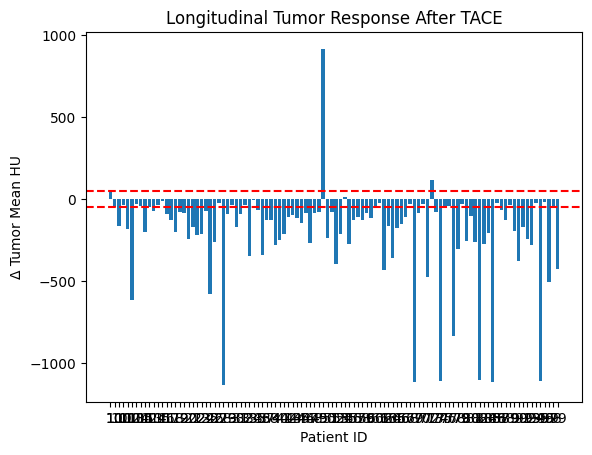

In [22]:
import matplotlib.pyplot as plt

plt.bar(df["patient_id"], df["delta_tumor_mean"])
plt.axhline(THRESH, color="red", linestyle="--")
plt.axhline(-THRESH, color="red", linestyle="--")
plt.xlabel("Patient ID")
plt.ylabel("Δ Tumor Mean HU")
plt.title("Longitudinal Tumor Response After TACE")
plt.show()


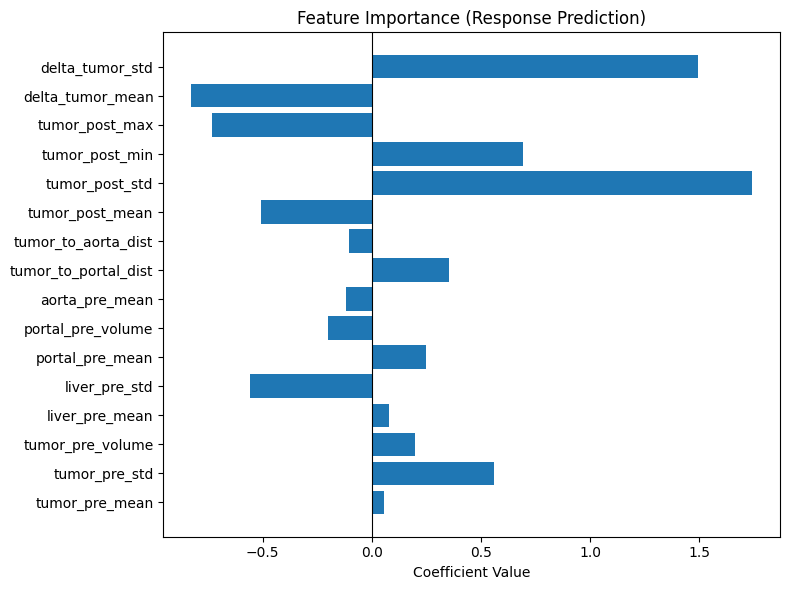

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Get feature names BEFORE scaling
feature_names = df.drop(columns=["patient_id", "response"]).columns

# 2️⃣ Coefficients from trained model
coef = model.coef_[0]

# 3️⃣ Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(feature_names, coef)
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Response Prediction)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [24]:
!pip install torch-geometric

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

print("✅ torch_geometric GPU installation successful")


C:\Users\GAYATHRI\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ torch_geometric GPU installation successful


In [26]:
import torch
from torch_geometric.data import Data

def build_graph(row):
    x = torch.tensor([
        [row.tumor_pre_mean, row.tumor_post_mean, row.delta_tumor_mean, row.tumor_pre_volume],
        [row.portal_pre_mean, 0, 0, row.portal_pre_volume],
        [row.aorta_pre_mean, 0, 0, 0],
        [row.liver_pre_mean, 0, 0, 0]
    ], dtype=torch.float)

    edge_index = torch.tensor([
        [0, 1, 0, 2, 0, 3],
        [1, 0, 2, 0, 3, 0]
    ], dtype=torch.long)

    y = torch.tensor(row.response, dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)


In [30]:
graphs = [build_graph(row) for _, row in df.iterrows()]


In [31]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool

class HepatoGAT(nn.Module):
    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=4,
            out_channels=32,
            heads=2,
            dropout=0.3,
            concat=True
        )

        self.gat2 = GATConv(
            in_channels=64,
            out_channels=32,
            heads=1,
            dropout=0.3,
            concat=False
        )

        self.fc = nn.Linear(32, 2)

    def forward(self, data, return_attention=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        if return_attention:
            x, attn1 = self.gat1(
                x, edge_index, return_attention_weights=True
            )
            x = x.relu()

            x, attn2 = self.gat2(
                x, edge_index, return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index).relu()
            x = self.gat2(x, edge_index)

        x = global_mean_pool(x, batch)
        out = self.fc(x)

        if return_attention:
            return out, attn1, attn2
        return out


In [32]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_graphs, test_graphs = train_test_split(
    graphs, test_size=0.2, random_state=42
)

train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=8)

model = HepatoGAT()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()


In [33]:
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
import numpy as np

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader):
    model.eval()
    correct, total = 0, 0
    probs_all, y_all = [], []

    with torch.no_grad():
        for data in loader:
            out = model(data)
            probs = torch.softmax(out, dim=1)[:, 1]
            pred = out.argmax(dim=1)

            correct += int((pred == data.y).sum())
            total += data.y.size(0)

            probs_all.extend(probs.cpu().numpy())
            y_all.extend(data.y.cpu().numpy())

    acc = correct / total
    return acc, np.array(probs_all), np.array(y_all)
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
import numpy as np

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader):
    model.eval()
    correct, total = 0, 0
    probs_all, y_all = [], []

    with torch.no_grad():
        for data in loader:
            out = model(data)
            probs = torch.softmax(out, dim=1)[:, 1]
            pred = out.argmax(dim=1)

            correct += int((pred == data.y).sum())
            total += data.y.size(0)

            probs_all.extend(probs.cpu().numpy())
            y_all.extend(data.y.cpu().numpy())

    acc = correct / total
    return acc, np.array(probs_all), np.array(y_all)


In [34]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool

class HepatoGAT(nn.Module):
    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=4,
            out_channels=32,
            heads=2,
            dropout=0.3,
            concat=True
        )

        self.gat2 = GATConv(
            in_channels=64,
            out_channels=32,
            heads=1,
            dropout=0.3,
            concat=False
        )

        self.fc = nn.Linear(32, 2)

    def forward(self, data, return_attention=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        if return_attention:
            x, attn1 = self.gat1(
                x, edge_index, return_attention_weights=True
            )
            x = x.relu()

            x, attn2 = self.gat2(
                x, edge_index, return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index).relu()
            x = self.gat2(x, edge_index)

        x = global_mean_pool(x, batch)
        out = self.fc(x)

        if return_attention:
            return out, attn1, attn2
        return out


In [35]:
model = HepatoGAT()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()


In [36]:
model.eval()

sample = test_graphs[0]

with torch.no_grad():
    out, attn1, attn2 = model(sample, return_attention=True)

# attn1 format: (edge_index, attention_weights)
edge_index, alpha = attn1


In [37]:
# alpha shape: [num_edges, num_heads]
alpha = alpha.mean(dim=1).cpu().numpy()   # average over heads
edges = edge_index.cpu().numpy()


In [38]:
import pandas as pd

edge_names = []
for src, dst in edges.T:
    edge_names.append(f"{src} → {dst}")

attn_df = pd.DataFrame({
    "Edge": edge_names,
    "Attention": alpha
})

attn_df = attn_df.sort_values("Attention", ascending=False)
attn_df


,Edge,Attention
1,1 → 0,1.000000e+00
2,0 → 2,1.000000e+00
7,1 → 1,1.000000e+00
4,0 → 3,1.000000e+00
0,0 → 1,1.000400e-29
6,0 → 0,1.000400e-29
5,3 → 0,0.000000e+00
3,2 → 0,0.000000e+00
8,2 → 2,0.000000e+00
9,3 → 3,0.000000e+00


In [39]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool

class HepatoGAT(nn.Module):
    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=4,
            out_channels=32,
            heads=2,
            concat=True,
            dropout=0.3
        )

        self.gat2 = GATConv(
            in_channels=64,
            out_channels=32,
            heads=1,
            concat=False,
            dropout=0.3
        )

        self.fc = nn.Linear(32, 2)

    def forward(self, data, return_attention=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        if return_attention:
            x, attn1 = self.gat1(
                x, edge_index, return_attention_weights=True
            )
            x = x.relu()

            x, attn2 = self.gat2(
                x, edge_index, return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index).relu()
            x = self.gat2(x, edge_index)

        x = global_mean_pool(x, batch)
        out = self.fc(x)

        if return_attention:
            return out, attn1, attn2
        return out


In [40]:
model = HepatoGAT()
model.eval()


HepatoGAT(
  (gat1): GATConv(4, 32, heads=2)
  (gat2): GATConv(64, 32, heads=1)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)

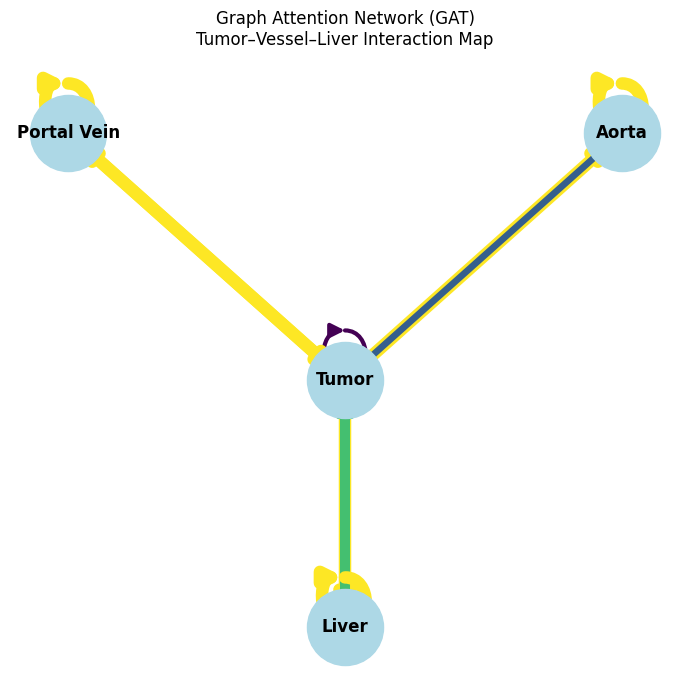

In [41]:
# ============================================================
# GNN Diagram Visualization using Edge Attention (FINAL)
# ============================================================

import torch
import networkx as nx
import matplotlib.pyplot as plt

# Pick one patient graph
sample = test_graphs[0]

# Extract attention
with torch.no_grad():
    out, attn1, attn2 = model(sample, return_attention=True)

# attn1 = (edge_index, attention_weights)
edge_index, alpha = attn1

# Average over attention heads
alpha = alpha.mean(dim=1).cpu().numpy()
edges = edge_index.cpu().numpy()

# Node labels (must match graph creation)
node_names = {
    0: "Tumor",
    1: "Portal Vein",
    2: "Aorta",
    3: "Liver"
}

# Build NetworkX graph
G = nx.DiGraph()

for idx, name in node_names.items():
    G.add_node(idx, label=name)

# Normalize attention for visualization
alpha_norm = (alpha - alpha.min()) / (alpha.max() - alpha.min() + 1e-6)

for (src, dst), w in zip(edges.T, alpha_norm):
    G.add_edge(src, dst, weight=w)

# Fixed biological layout
pos = {
    0: (0, 0),     # Tumor
    1: (-1, 1),    # Portal vein
    2: (1, 1),     # Aorta
    3: (0, -1)     # Liver
}

# Plot
plt.figure(figsize=(7,7))

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="lightblue")
nx.draw_networkx_labels(G, pos, labels=node_names, font_size=12, font_weight="bold")

weights = [d["weight"] for (_, _, d) in G.edges(data=True)]

nx.draw_networkx_edges(
    G, pos,
    edge_color=weights,
    edge_cmap=plt.cm.viridis,
    width=[3 + 6*w for w in weights],
    arrows=True,
    arrowsize=20
)

plt.title("Graph Attention Network (GAT)\nTumor–Vessel–Liver Interaction Map")
plt.axis("off")
plt.tight_layout()
plt.show()


In [42]:
def mean_attention(graphs, model):
    all_alpha = []
    with torch.no_grad():
        for g in graphs:
            _, attn, _ = model(g, return_attention=True)
            _, alpha = attn
            all_alpha.append(alpha.mean(dim=1))
    return torch.stack(all_alpha).mean(dim=0)


In [43]:
node_importance = np.zeros(4)
for (src, dst), w in zip(edges.T, alpha):
    node_importance[dst] += w


Alpha shape: torch.Size([10, 2])


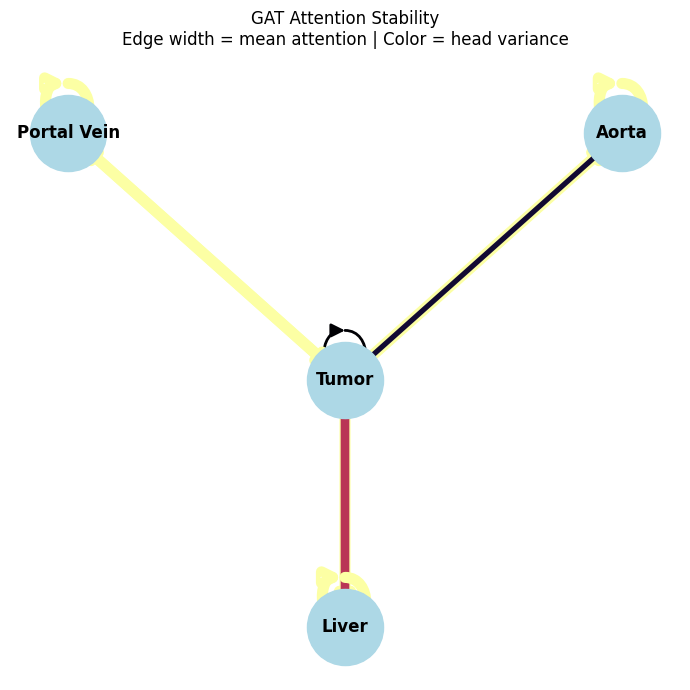

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------------------------
# 1. Pick one test graph
# -------------------------------------------------
sample = test_graphs[0]

# -------------------------------------------------
# 2. Forward pass with attention
# -------------------------------------------------
model.eval()
with torch.no_grad():
    out, attn1, attn2 = model(sample, return_attention=True)

# -------------------------------------------------
# 3. Unpack attention
# -------------------------------------------------
edge_index, alpha_heads = attn1
# alpha_heads shape: (num_edges, num_heads)

alpha_heads = alpha_heads.cpu()
edge_index = edge_index.cpu()

print("Alpha shape:", alpha_heads.shape)

# -------------------------------------------------
# 4. Compute mean + variance across heads
# -------------------------------------------------
alpha_mean = alpha_heads.mean(dim=1).numpy()
alpha_var  = alpha_heads.var(dim=1).numpy()

# -------------------------------------------------
# 5. Build NetworkX graph
# -------------------------------------------------
node_names = {
    0: "Tumor",
    1: "Portal Vein",
    2: "Aorta",
    3: "Liver"
}

G = nx.DiGraph()

for i, name in node_names.items():
    G.add_node(i, label=name)

# Normalize for visualization
mean_norm = (alpha_mean - alpha_mean.min()) / (alpha_mean.max() - alpha_mean.min() + 1e-6)
var_norm  = (alpha_var  - alpha_var.min())  / (alpha_var.max()  - alpha_var.min()  + 1e-6)

for (src, dst), w_mean, w_var in zip(edge_index.T, mean_norm, var_norm):
    G.add_edge(
        src.item(),
        dst.item(),
        weight=w_mean,
        var=w_var
    )

# -------------------------------------------------
# 6. Fixed biological layout
# -------------------------------------------------
pos = {
    0: (0, 0),     # Tumor
    1: (-1, 1),    # Portal Vein
    2: (1, 1),     # Aorta
    3: (0, -1)     # Liver
}

# -------------------------------------------------
# 7. Plot mean attention (thickness)
# -------------------------------------------------
plt.figure(figsize=(7,7))

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="lightblue")
nx.draw_networkx_labels(G, pos, labels=node_names, font_size=12, font_weight="bold")

edges = G.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]
vars_   = [d["var"] for (_, _, d) in edges]

nx.draw_networkx_edges(
    G,
    pos,
    width=[2 + 6*w for w in weights],
    edge_color=vars_,            # VARIANCE as color
    edge_cmap=plt.cm.inferno,    # High variance = unstable
    arrows=True,
    arrowsize=20
)

plt.title(
    "GAT Attention Stability\n"
    "Edge width = mean attention | Color = head variance"
)
plt.axis("off")
plt.tight_layout()
plt.show()


In [45]:
import torch

def build_feature_tensor(row):
    # Nodes: Tumor, Portal, Aorta, Liver
    return torch.tensor([
        [row.tumor_pre_mean, row.tumor_post_mean, row.delta_tumor_mean, row.tumor_pre_volume],
        [row.portal_pre_mean, 0, 0, row.portal_pre_volume],
        [row.aorta_pre_mean, 0, 0, 0],
        [row.liver_pre_mean, 0, 0, 0]
    ], dtype=torch.float)


In [46]:
import torch.nn as nn

class HepatoAttentionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(4, 32)
        self.attn = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        # x shape: [B, N_nodes, N_features]
        x = self.embed(x)
        attn_out, _ = self.attn(x, x, x)
        pooled = attn_out.mean(dim=1)
        return self.classifier(pooled)


In [47]:
from sklearn.model_selection import train_test_split

X = torch.stack([build_feature_tensor(row) for _, row in df.iterrows()])
y = torch.tensor(df["response"].values, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = HepatoAttentionNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        preds = model(X_test).argmax(dim=1)
        acc = (preds == y_test).float().mean().item()
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Test Acc {acc:.3f}")


Epoch 010 | Loss 112.1708 | Test Acc 0.571
Epoch 020 | Loss 199.3481 | Test Acc 0.762
Epoch 030 | Loss 73.7910 | Test Acc 0.762
Epoch 040 | Loss 65.6477 | Test Acc 0.762
Epoch 050 | Loss 33.4177 | Test Acc 0.714
Epoch 060 | Loss 19.5143 | Test Acc 0.333
Epoch 070 | Loss 27.7860 | Test Acc 0.762
Epoch 080 | Loss 33.9822 | Test Acc 0.762
Epoch 090 | Loss 61.2673 | Test Acc 0.714
Epoch 100 | Loss 50.2464 | Test Acc 0.762
Epoch 110 | Loss 26.8646 | Test Acc 0.714
Epoch 120 | Loss 20.1995 | Test Acc 0.333
Epoch 130 | Loss 81.8423 | Test Acc 0.667
Epoch 140 | Loss 42.5833 | Test Acc 0.762
Epoch 150 | Loss 16.3500 | Test Acc 0.762
Epoch 160 | Loss 39.7927 | Test Acc 0.714
Epoch 170 | Loss 37.8915 | Test Acc 0.762
Epoch 180 | Loss 18.1684 | Test Acc 0.619
Epoch 190 | Loss 13.0374 | Test Acc 0.286
Epoch 200 | Loss 104.2249 | Test Acc 0.667
Epoch 210 | Loss 30.4111 | Test Acc 0.762
Epoch 220 | Loss 36.1699 | Test Acc 0.762
Epoch 230 | Loss 30.0519 | Test Acc 0.762
Epoch 240 | Loss 36.1757 | Test

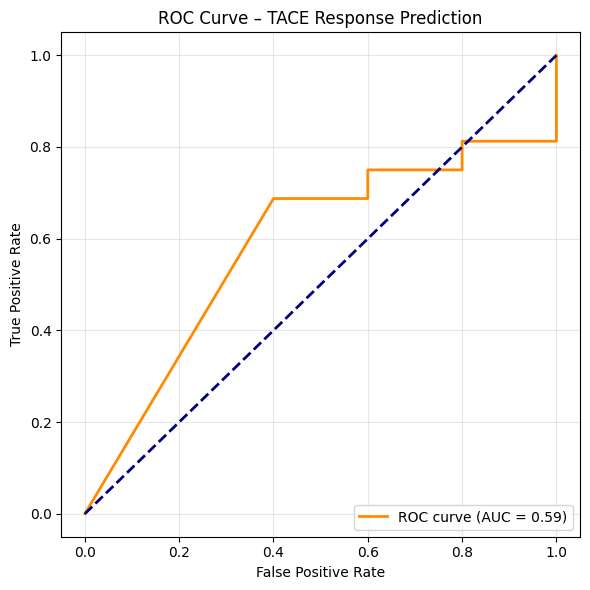

✅ AUC: 0.588


In [48]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ensure model is in eval mode
model.eval()

# Get prediction probabilities
with torch.no_grad():
    logits = model(X_test)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

y_true = y_test.cpu().numpy()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange",
         lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – TACE Response Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ AUC: {roc_auc:.3f}")


In [49]:
import torch
import torch.nn as nn

class HepatoAttentionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(4, 32)
        self.attn = nn.MultiheadAttention(
            embed_dim=32,
            num_heads=4,
            batch_first=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x, return_attention=False):
        x = self.embed(x)                     # [B, N_nodes, 32]
        attn_out, attn_weights = self.attn(x, x, x)
        pooled = attn_out.mean(dim=1)
        logits = self.classifier(pooled)

        if return_attention:
            return logits, attn_weights
        return logits


In [50]:
model = HepatoAttentionNet()

In [51]:
model.eval()

idx = 0  # patient index

with torch.no_grad():
    logits, attn = model(
        X_test[idx:idx+1],
        return_attention=True
    )

print("Raw attention shape:", attn.shape)


Raw attention shape: torch.Size([1, 4, 4])


In [52]:
# attn shape is already [B, N_nodes, N_nodes]
attn_mat = attn.squeeze(0).cpu().numpy()

print("Final attention matrix shape:", attn_mat.shape)


Final attention matrix shape: (4, 4)


In [53]:
# attn shape: [B, num_heads, N_nodes, N_nodes]
attn_mat = attn.mean(dim=1)   # average over heads → [B, 4, 4]
attn_mat = attn_mat.squeeze(0)  # remove batch dim → [4, 4]

attn_mat = attn_mat.cpu().numpy()

print("Processed attention shape:", attn_mat.shape)


Processed attention shape: (4,)


In [54]:
import torch
import os

# ===============================
# SAVE PATH (LOCAL)
# ===============================
SAVE_PATH = r"D:\TACE\hepato_gat.pth"

# Ensure folder exists
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# Save model
torch.save(model.state_dict(), SAVE_PATH)

print(f"✅ Model saved at: {SAVE_PATH}")

✅ Model saved at: D:\TACE\hepato_gat.pth


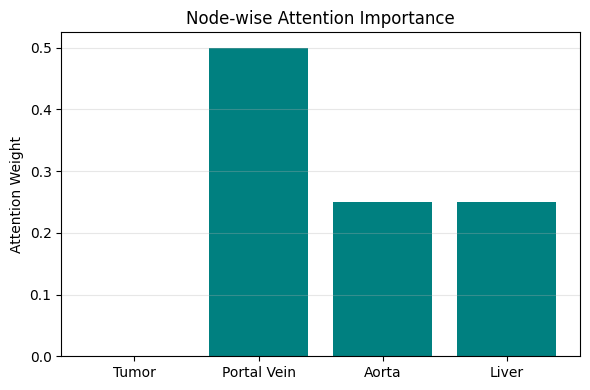

In [55]:
import matplotlib.pyplot as plt
import numpy as np

node_names = ["Tumor", "Portal Vein", "Aorta", "Liver"]

attn_vec = np.asarray(attn_mat)

assert attn_vec.shape == (4,), f"Expected (4,), got {attn_vec.shape}"

plt.figure(figsize=(6, 4))
plt.bar(node_names, attn_vec, color="teal")
plt.ylabel("Attention Weight")
plt.title("Node-wise Attention Importance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [56]:
def get_patient_summary(df, pid):

    THRESH = 50

    row = df[df["patient_id"] == pid].copy()

    row["response"] = (abs(row["delta_tumor_mean"]) >= THRESH).astype(int)

    response_label = "Responder" if row["response"].values[0] == 1 else "Non-Responder"

    return row, response_label

In [57]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_distance_connectome(row):

    G = nx.Graph()

    # Nodes
    G.add_node("Tumor", color="red", size=row["tumor_pre_volume"] / 50)
    G.add_node("Portal Vein", color="blue", size=1500)
    G.add_node("Aorta", color="blue", size=1500)
    G.add_node("Parenchyma", color="green", size=2000)

    # --- IMPORTANT EDGES (ONLY 3) ---
    d_tp = row["tumor_to_portal_dist"]
    d_ta = row["tumor_to_aorta_dist"]

    # OPTIONAL derived distance (tumor–liver relation proxy)
    d_tl = (d_tp + d_ta) / 2  

    G.add_edge("Tumor", "Portal Vein", label=f"{d_tp:.1f} mm", weight=1/d_tp)
    G.add_edge("Tumor", "Aorta", label=f"{d_ta:.1f} mm", weight=1/d_ta)
    G.add_edge("Tumor", "Parenchyma", label=f"{d_tl:.1f} mm", weight=1/d_tl)

    # Layout (same as your image)
    pos = {
        "Tumor": (0, 0),
        "Portal Vein": (-1.5, 1),
        "Aorta": (1.5, 1),
        "Parenchyma": (0, 2)
    }

    colors = [G.nodes[n]["color"] for n in G.nodes()]
    sizes  = [G.nodes[n]["size"] for n in G.nodes()]

    plt.figure(figsize=(7,7))

    nx.draw(
        G, pos,
        with_labels=True,
        node_color=colors,
        node_size=sizes,
        font_weight="bold"
    )

    # Edge labels (DISTANCE)
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Title with tumor volume
    plt.title(f"Connectome | Tumor Volume: {int(row['tumor_pre_volume'])} mm³")

    plt.axis("off")
    return plt

In [58]:
def final_patient_output(df, pid):

    row_df, response_label = get_patient_summary(df, pid)
    row = row_df.iloc[0]

    print("\n🧾 PATIENT FEATURES:\n")
    display(row_df)

    print(f"\n🎯 RESPONSE: {response_label}")

    print("\n🧠 CONNECTOME GRAPH (DISTANCE-BASED):\n")
    plot = plot_distance_connectome(row)
    plot.show()

In [59]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

# =========================
# PATH FIX (LOCAL)
# =========================
MODEL_PATH = r"D:\TACE\hepato_gat.pth"

# =========================
# MODEL DEFINITION
# =========================
class HepatoAttentionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(4, 32)

        self.attn = nn.MultiheadAttention(
            embed_dim=32,
            num_heads=4,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x, return_attention=False):
        x = self.embed(x)
        attn_out, attn_weights = self.attn(x, x, x)
        pooled = attn_out.mean(dim=1)
        logits = self.classifier(pooled)

        if return_attention:
            return logits, attn_weights
        return logits


# =========================
# LOAD MODEL (FIXED)
# =========================
model = HepatoAttentionNet()

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

state_dict = torch.load(MODEL_PATH, map_location="cpu")

# ✅ HANDLE BOTH CASES (important)
if "model_state_dict" in state_dict:
    model.load_state_dict(state_dict["model_state_dict"])
else:
    model.load_state_dict(state_dict)

model.eval()

print("✅ Model loaded successfully")


# =========================
# RESPONSE FUNCTION
# =========================
def get_response(row):
    THRESH = 50
    return "Responder" if abs(row["delta_tumor_mean"]) >= THRESH else "Non-Responder"


# =========================
# CONNECTOME PLOT (FIXED)
# =========================
def plot_connectome(row):

    G = nx.Graph()

    # Distances (safe handling)
    d_tp = float(row.get("tumor_to_portal_dist", 0))
    d_ta = float(row.get("tumor_to_aorta_dist", 0))
    d_tl = (d_tp + d_ta) / 2

    # Graph
    G.add_edge("Tumor", "Portal Vein", label=f"{d_tp:.1f} mm")
    G.add_edge("Tumor", "Aorta", label=f"{d_ta:.1f} mm")
    G.add_edge("Tumor", "Parenchyma", label=f"{d_tl:.1f} mm")

    pos = {
        "Tumor": (0, 0),
        "Portal Vein": (-2, 1),
        "Aorta": (2, 1),
        "Parenchyma": (0, 2)
    }

    fig, ax = plt.subplots(figsize=(6, 6))

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=[3000, 2000, 2000, 2500],
        node_color=["red", "blue", "blue", "green"],
        font_weight="bold",
        ax=ax
    )

    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    vol = int(row.get("tumor_pre_volume", 0))
    ax.set_title(f"Tumor Volume: {vol} mm³")
    ax.axis("off")

    return fig

✅ Model loaded successfully


In [60]:
import SimpleITK as sitk
import numpy as np
import nibabel as nib
import os


In [61]:
import numpy as np
from scipy.ndimage import (
    binary_dilation,
    binary_closing,
    binary_opening,
    label,
    distance_transform_edt
)

def segment_post_tumor_region_guided(
    post_ct,
    pre_tumor_mask,
    viable_hu=(50, 220),
    peri_margin_iters=6,
    min_component_size=120,
    max_mean_distance=25
):
    """
    Robust post-TACE viable tumor segmentation.

    Uses:
    - Core + peritumoral zone
    - Two-pass logic to handle lipiodol-mixed viability
    """

    pre_tumor_mask = pre_tumor_mask.astype(bool)

    # -------------------------
    # 1. Allowed region
    # -------------------------
    core = pre_tumor_mask
    peri = binary_dilation(pre_tumor_mask, iterations=peri_margin_iters)
    allowed = core | peri

    # -------------------------
    # 2. PASS 1: Strict viable HU
    # -------------------------
    candidate = (
        (post_ct > viable_hu[0]) &
        (post_ct < viable_hu[1]) &
        allowed
    )

    # -------------------------
    # 3. PASS 2: Lipiodol-adjacent rescue
    # -------------------------
    if candidate.sum() < min_component_size:
        # include high-HU tissue ONLY near tumor
        candidate = (
            (post_ct > viable_hu[0]) &
            allowed
        )

    if candidate.sum() == 0:
        return np.zeros_like(candidate, dtype=np.uint8)

    # -------------------------
    # 4. Connected components
    # -------------------------
    labeled, num = label(candidate)

    dist_map = distance_transform_edt(~pre_tumor_mask)
    final = np.zeros_like(candidate, dtype=np.uint8)

    for comp in range(1, num + 1):
        comp_mask = (labeled == comp)

        if comp_mask.sum() < min_component_size:
            continue

        if dist_map[comp_mask].mean() > max_mean_distance:
            continue

        final |= comp_mask

    if final.sum() == 0:
        return np.zeros_like(candidate, dtype=np.uint8)

    # -------------------------
    # 5. Cleanup
    # -------------------------
    final = binary_closing(final, iterations=2)
    final = binary_opening(final, iterations=1)

    return final.astype(np.uint8)


In [62]:
import numpy as np
from scipy.ndimage import binary_dilation

def compute_tumor_metrics(
    pre_mask,
    post_viable_mask,
    spacing,                 # (Z, Y, X)
    recurrence_margin_mm=10
):
    """
    Post-TACE tumor response metrics (mRECIST-ready).
    """

    # -------------------------
    # Safety checks
    # -------------------------
    if np.sum(pre_mask) == 0:
        raise ValueError("PRE tumor mask is empty — cannot compute metrics.")

    voxel_volume = spacing[0] * spacing[1] * spacing[2]

    # -------------------------
    # Volumes
    # -------------------------
    pre_voxels = np.sum(pre_mask)
    viable_voxels = np.sum(post_viable_mask)

    pre_volume = pre_voxels * voxel_volume
    viable_volume = viable_voxels * voxel_volume

    viable_fraction = viable_volume / (pre_volume + 1e-6)

    # -------------------------
    # Residual vs recurrence
    # -------------------------
    # Use IN-PLANE spacing for dilation (clinically correct)
    inplane_spacing = min(spacing[1], spacing[2])
    margin_voxels = max(1, int(recurrence_margin_mm / inplane_spacing))

    expanded_pre = binary_dilation(
        pre_mask,
        iterations=margin_voxels
    )

    residual_mask = post_viable_mask & expanded_pre
    recurrence_mask = post_viable_mask & (~expanded_pre)

    residual_volume = np.sum(residual_mask) * voxel_volume
    recurrence_volume = np.sum(recurrence_mask) * voxel_volume

    # -------------------------
    # Debug / QC flags
    # -------------------------
    empty_viable = viable_voxels == 0

    return {
        "pre_tumor_volume_mm3": pre_volume,
        "post_viable_volume_mm3": viable_volume,
        "viable_fraction": viable_fraction,
        "residual_viable_volume_mm3": residual_volume,
        "recurrence_volume_mm3": recurrence_volume,
        "empty_post_viable_mask": empty_viable,
        "recurrence_margin_voxels": margin_voxels
    }


In [63]:
def classify_mrecist(
    pre_vol,
    post_viable_vol,
    recurrence_vol,
    empty_post_viable_mask=False,
    cr_thresh=0.10,
    pr_thresh=0.30,
    pd_rel_thresh=0.20,
    pd_abs_thresh_mm3=500
):
    """
    mRECIST-like response classification using viable tumor volume.
    """

    # -------------------------
    # Complete Response (CR)
    # -------------------------
    # Empty viable mask OR very small viable volume = CR
    if empty_post_viable_mask or post_viable_vol <= cr_thresh * pre_vol:
        return "CR"

    # -------------------------
    # Progressive Disease (PD)
    # -------------------------
    # New viable tumor outside original region
    if (
        recurrence_vol > pd_abs_thresh_mm3 or
        recurrence_vol > pd_rel_thresh * pre_vol
    ):
        return "PD"

    # -------------------------
    # Partial Response (PR)
    # -------------------------
    reduction = (pre_vol - post_viable_vol) / (pre_vol + 1e-6)
    if reduction >= pr_thresh:
        return "PR"

    # -------------------------
    # Stable Disease (SD)
    # -------------------------
    return "SD"


In [64]:
import numpy as np
from scipy.ndimage import zoom

def align_mask_to_post(pre_mask, post_ct):
    """
    Align PRE tumor mask to POST CT by Z-axis resampling.
    Accurate version using nearest-neighbor interpolation.
    """

    D_pre, H_pre, W_pre = pre_mask.shape
    D_post, H_post, W_post = post_ct.shape

    # -------------------------
    # Safety: spatial consistency
    # -------------------------
    if (H_pre != H_post) or (W_pre != W_post):
        raise ValueError(
            f"Shape mismatch: PRE mask {(H_pre, W_pre)} "
            f"vs POST CT {(H_post, W_post)}"
        )

    # -------------------------
    # Z-axis resampling
    # -------------------------
    scale_z = D_post / D_pre

    aligned = zoom(
        pre_mask,
        zoom=(scale_z, 1, 1),
        order=0,           # nearest neighbor (labels)
        mode="constant",
        cval=0
    )

    # -------------------------
    # Enforce exact depth
    # -------------------------
    if aligned.shape[0] > D_post:
        aligned = aligned[:D_post]
    elif aligned.shape[0] < D_post:
        aligned = np.pad(
            aligned,
            ((0, D_post - aligned.shape[0]), (0, 0), (0, 0)),
            mode="constant"
        )

    return aligned.astype(np.uint8)


In [ ]:
import os
import nibabel as nib
import pandas as pd
from tqdm import tqdm
import numpy as np

# ===============================
# PATHS (FIXED)
# ===============================
BASE = r"D:\TACE\processed"
PRE_DIR  = os.path.join(BASE, "pre")
POST_DIR = os.path.join(BASE, "post")

results = []

print("🚀 Running Post-TACE Tumor Analysis\n")

# Make sure dataset_df exists from your previous steps
for idx, row in tqdm(
    dataset_df.iterrows(),
    total=len(dataset_df),
    desc="Post-TACE Tumor Analysis"
):

    pid = str(row.patient_id)

    try:
        # -------------------------
        # Paths - UPDATED MASK PATH
        # -------------------------
        pre_path  = os.path.join(PRE_DIR,  f"{pid}_pre_ct.nii.gz")
        post_path = os.path.join(POST_DIR, f"{pid}_post_ct.nii.gz")
        
        # Check PRE_DIR first, then BASE as fallback
        mask_path = os.path.join(PRE_DIR, f"{pid}_Mass.nii.gz")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(BASE, f"{pid}_Mass.nii.gz")

        # -------------------------
        # Strict Check existence
        # -------------------------
        if not os.path.exists(pre_path): raise FileNotFoundError(f"Missing PRE CT: {pre_path}")
        if not os.path.exists(post_path): raise FileNotFoundError(f"Missing POST CT: {post_path}")
        if not os.path.exists(mask_path): raise FileNotFoundError(f"Missing MASK: {mask_path}")

        # -------------------------
        # Load volumes
        # -------------------------
        pre_ct_nii  = nib.load(pre_path)
        post_ct_nii = nib.load(post_path)
        mask_nii    = nib.load(mask_path)

        pre_ct  = pre_ct_nii.get_fdata()
        post_ct = post_ct_nii.get_fdata()
        pre_mask = mask_nii.get_fdata() > 0 

        # -------------------------
        # Spacing (Important for Volume)
        # -------------------------
        # get_zooms() returns (dx, dy, dz)
        spacing = tuple(post_ct_nii.header.get_zooms())

        # -------------------------
        # Processing Steps
        # (Assuming these functions are defined in your environment)
        # -------------------------
        
        # 1. Align PRE mask to POST CT space
        pre_mask_aligned = align_mask_to_post(pre_mask, post_ct)

        # 2. Find high-intensity regions in the POST CT near the original tumor
        post_viable_mask = segment_post_tumor_region_guided(post_ct, pre_mask_aligned)

        # 3. Compute volumes in mm³
        metrics = compute_tumor_metrics(
            pre_mask=pre_mask_aligned,
            post_viable_mask=post_viable_mask,
            spacing=spacing
        )

        # 4. mRECIST classification (CR, PR, SD, PD)
        response = classify_mrecist(
            pre_vol=metrics["pre_tumor_volume_mm3"],
            post_viable_vol=metrics["post_viable_volume_mm3"],
            recurrence_vol=metrics["recurrence_volume_mm3"],
            empty_post_viable_mask=metrics["empty_post_viable_mask"]
        )

        metrics["patient_id"] = pid
        metrics["mRECIST_response"] = response

        if metrics.get("empty_post_viable_mask"):
            # This usually means Complete Response (CR)
            pass 

        results.append(metrics)

    except Exception as e:
        print(f"❌ Patient {pid} failed → {e}")
        continue

# ===============================
# Final DataFrame
# ===============================
if results:
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("patient_id").reset_index(drop=True)
    st.write(results_df) # If running in Streamlit
else:
    print("No results generated. Check file paths.")

🚀 Running Post-TACE Tumor Analysis



Post-TACE Tumor Analysis:  36%|███▌      | 38/105 [43:05<47:31, 42.56s/it]    

❌ Patient 39 failed → Missing PRE CT: D:\TACE\processed\pre\39_pre_ct.nii.gz


Post-TACE Tumor Analysis:  99%|█████████▉| 104/105 [1:58:25<00:31, 31.72s/it]  

In [65]:
import os
import nibabel as nib
import pandas as pd
from tqdm import tqdm

# ===============================
# PATHS (FIXED)
# ===============================
BASE = r"D:\TACE\processed"
PRE_DIR  = os.path.join(BASE, "pre")
POST_DIR = os.path.join(BASE, "post")

results = []

print("🚀 Running Post-TACE Tumor Analysis\n")

for idx, row in tqdm(
    dataset_df.iterrows(),
    total=len(dataset_df),
    desc="Post-TACE Tumor Analysis"
):

    pid = str(row.patient_id)

    try:
        # -------------------------
        # Paths
        # -------------------------
        pre_path  = os.path.join(PRE_DIR,  f"{pid}_pre_ct.nii.gz")
        post_path = os.path.join(POST_DIR, f"{pid}_post_ct.nii.gz")
        mask_path = os.path.join(BASE, f"{pid}_Mass.nii.gz")

        # -------------------------
        # Check existence
        # -------------------------
        for p in [pre_path, post_path, mask_path]:
            if not os.path.exists(p):
                raise FileNotFoundError(p)

        # -------------------------
        # Load volumes
        # -------------------------
        pre_ct_nii  = nib.load(pre_path)
        post_ct_nii = nib.load(post_path)

        pre_ct  = pre_ct_nii.get_fdata()
        post_ct = post_ct_nii.get_fdata()

        pre_mask = nib.load(mask_path).get_fdata() > 0   # ✅ FIXED

        # -------------------------
        # Spacing (SAFE)
        # -------------------------
        spacing = tuple(post_ct_nii.header.get_zooms())[::-1]

        # -------------------------
        # Align PRE → POST
        # -------------------------
        pre_mask_aligned = align_mask_to_post(
            pre_mask,
            post_ct
        )

        # -------------------------
        # Segment POST viable tumor
        # -------------------------
        post_viable_mask = segment_post_tumor_region_guided(
            post_ct,
            pre_mask_aligned
        )

        # -------------------------
        # Compute metrics
        # -------------------------
        metrics = compute_tumor_metrics(
            pre_mask=pre_mask_aligned,
            post_viable_mask=post_viable_mask,
            spacing=spacing
        )

        # -------------------------
        # mRECIST classification
        # -------------------------
        response = classify_mrecist(
            pre_vol=metrics["pre_tumor_volume_mm3"],
            post_viable_vol=metrics["post_viable_volume_mm3"],
            recurrence_vol=metrics["recurrence_volume_mm3"],
            empty_post_viable_mask=metrics["empty_post_viable_mask"]
        )

        metrics["patient_id"] = pid
        metrics["mRECIST_response"] = response

        # -------------------------
        # Debug
        # -------------------------
        if metrics["empty_post_viable_mask"]:
            print(f"⚠️ Empty viable mask for patient {pid}")

        results.append(metrics)

    except Exception as e:
        print(f"❌ Patient {pid} failed → {e}")
        continue

# ===============================
# Final DataFrame
# ===============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("patient_id").reset_index(drop=True)

results_df

🚀 Running Post-TACE Tumor Analysis



Post-TACE Tumor Analysis: 100%|██████████| 105/105 [00:00<00:00, 5423.47it/s]

❌ Patient 1 failed → D:\TACE\processed\1_Mass.nii.gz
❌ Patient 10 failed → D:\TACE\processed\10_Mass.nii.gz
❌ Patient 100 failed → D:\TACE\processed\100_Mass.nii.gz
❌ Patient 101 failed → D:\TACE\processed\101_Mass.nii.gz
❌ Patient 102 failed → D:\TACE\processed\102_Mass.nii.gz
❌ Patient 103 failed → D:\TACE\processed\103_Mass.nii.gz
❌ Patient 104 failed → D:\TACE\processed\104_Mass.nii.gz
❌ Patient 105 failed → D:\TACE\processed\105_Mass.nii.gz
❌ Patient 11 failed → D:\TACE\processed\11_Mass.nii.gz
❌ Patient 12 failed → D:\TACE\processed\12_Mass.nii.gz
❌ Patient 13 failed → D:\TACE\processed\13_Mass.nii.gz
❌ Patient 14 failed → D:\TACE\processed\14_Mass.nii.gz
❌ Patient 15 failed → D:\TACE\processed\15_Mass.nii.gz
❌ Patient 16 failed → D:\TACE\processed\16_Mass.nii.gz
❌ Patient 17 failed → D:\TACE\processed\17_Mass.nii.gz
❌ Patient 18 failed → D:\TACE\processed\18_Mass.nii.gz
❌ Patient 19 failed → D:\TACE\processed\19_Mass.nii.gz
❌ Patient 2 failed → D:\TACE\processed\2_Mass.nii.gz
❌ 

KeyError: 'patient_id'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_pre_post_overlay(
    pre_ct,
    post_ct,
    pre_mask,
    pre_mask_aligned,
    post_viable_mask,
    pid
):
    """
    QC-safe visualization for PRE vs POST tumor overlays
    """

    # -------------------------
    # Slice selection (ANCHOR TO PRE)
    # -------------------------
    if np.sum(pre_mask_aligned) > 0:
        z = np.argmax(np.sum(pre_mask_aligned, axis=(1, 2)))
    else:
        # extreme fallback (should rarely happen)
        z = post_ct.shape[0] // 2

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # PRE-TACE (original space)
    z_pre = np.argmax(np.sum(pre_mask, axis=(1, 2)))

    axes[0].imshow(pre_ct[z_pre], cmap="gray")
    axes[0].imshow(
        np.ma.masked_where(pre_mask[z_pre] == 0, pre_mask[z_pre]),
        cmap="Reds",
        alpha=0.5
    )
    axes[0].set_title(f"PRE-TACE Tumor | Patient {pid}")
    axes[0].axis("off")

    # POST-TACE (aligned comparison)
    axes[1].imshow(post_ct[z], cmap="gray")

    # PRE tumor (aligned)
    axes[1].imshow(
        np.ma.masked_where(pre_mask_aligned[z] == 0, pre_mask_aligned[z]),
        cmap="Reds",
        alpha=0.25
    )

    # POST viable tumor
    if np.sum(post_viable_mask) > 0:
        axes[1].imshow(
            np.ma.masked_where(post_viable_mask[z] == 0, post_viable_mask[z]),
            cmap="Blues",
            alpha=0.6
        )

    axes[1].set_title(f"POST-TACE QC Slice | Patient {pid}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

pid = results_df.patient_id.iloc[0]

pre_ct  = nib.load(f"{OUTPUT_DIR}/{pid}_pre_ct.nii.gz").get_fdata()
post_ct = nib.load(f"{OUTPUT_DIR}/{pid}_post_ct.nii.gz").get_fdata()

pre_mask = nib.load(
    f"{OUTPUT_DIR}/{pid}_Mass.nii.gz"
).get_fdata().astype(bool)

# Align PRE mask to POST CT
pre_mask_aligned = align_mask_to_post(pre_mask, post_ct)

# Segment POST viable tumor (FINAL version)
post_viable_mask = segment_post_tumor_region_guided(
    post_ct,
    pre_mask_aligned
)

# ✅ Correct visualization
visualize_pre_post_overlay(
    pre_ct,
    post_ct,
    pre_mask,
    pre_mask_aligned,
    post_viable_mask,
    pid
)


In [ ]:
import matplotlib.pyplot as plt

pid = results_df.patient_id.iloc[6]

pre_ct  = nib.load(f"{OUTPUT_DIR}/{pid}_pre_ct.nii.gz").get_fdata()
post_ct = nib.load(f"{OUTPUT_DIR}/{pid}_post_ct.nii.gz").get_fdata()

pre_mask = nib.load(
    f"{OUTPUT_DIR}/{pid}_Mass.nii.gz"
).get_fdata().astype(bool)

# Align PRE mask to POST CT
pre_mask_aligned = align_mask_to_post(pre_mask, post_ct)

# Segment POST viable tumor (FINAL version)
post_viable_mask = segment_post_tumor_region_guided(
    post_ct,
    pre_mask_aligned
)

# ✅ Correct visualization
visualize_pre_post_overlay(
    pre_ct,
    post_ct,
    pre_mask,
    pre_mask_aligned,
    post_viable_mask,
    pid
)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for _, row in results_df.iterrows():
    plt.plot(
        ["Pre-TACE", "Post-TACE"],
        [row["pre_tumor_volume_mm3"], row["post_viable_volume_mm3"]],
        marker="o",
        alpha=0.7
    )

plt.ylabel("Tumor Volume (mm³)")
plt.title("Tumor Volume Change After TACE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def volume_to_equivalent_diameter(volume_mm3):
    """
    Convert tumor volume (mm³) to equivalent spherical diameter (mm).
    """
    if volume_mm3 <= 0:
        return 0.0

    radius = ((3 * volume_mm3) / (4 * np.pi)) ** (1 / 3)
    return 2 * radius


In [ ]:
results_df["pre_diameter_mm"] = results_df["pre_tumor_volume_mm3"].apply(
    volume_to_equivalent_diameter
)

results_df["post_diameter_mm"] = results_df["post_viable_volume_mm3"].apply(
    volume_to_equivalent_diameter
)

results_df["diameter_change_pct"] = (
    (results_df["post_diameter_mm"] - results_df["pre_diameter_mm"])
    / (results_df["pre_diameter_mm"] + 1e-6)
)


In [ ]:
def mrecist_from_diameter(pre_d, post_d):
    if post_d == 0:
        return "CR"

    change = (post_d - pre_d) / (pre_d + 1e-6)

    if change <= -0.30:
        return "PR"
    elif change >= 0.20:
        return "PD"
    else:
        return "SD"


In [ ]:
results_df["mRECIST_diameter_based"] = results_df.apply(
    lambda r: mrecist_from_diameter(
        r["pre_diameter_mm"],
        r["post_diameter_mm"]
    ),
    axis=1
)


In [ ]:
pd.crosstab(
    results_df["mRECIST_response"],
    results_df["mRECIST_diameter_based"],
    rownames=["Volume-based"],
    colnames=["Diameter-based"]
)


In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
    results_df["mRECIST_response"],
    results_df["mRECIST_diameter_based"]
)

print("Cohen's kappa:", kappa)


In [ ]:
import matplotlib.pyplot as plt

sorted_df = results_df.sort_values("diameter_change_pct")

plt.figure(figsize=(10,5))
plt.bar(
    range(len(sorted_df)),
    sorted_df["diameter_change_pct"] * 100
)

plt.axhline(-30, color="green", linestyle="--", label="PR threshold (-30%)")
plt.axhline(20, color="red", linestyle="--", label="PD threshold (+20%)")

plt.ylabel("Diameter Change (%)")
plt.xlabel("Patients (sorted)")
plt.title("Waterfall Plot of Tumor Response (mRECIST-like)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,6))

for _, r in results_df.iterrows():
    plt.plot(
        ["Pre", "Post"],
        [r["pre_diameter_mm"], r["post_diameter_mm"]],
        marker="o",
        alpha=0.6
    )

plt.ylabel("Equivalent Tumor Diameter (mm)")
plt.title("Pre- vs Post-TACE Tumor Diameter")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
results_summary = results_df[[
    "patient_id",
    "pre_diameter_mm",
    "post_diameter_mm",
    "diameter_change_pct",
    "mRECIST_response",
    "mRECIST_diameter_based"
]]

results_summary
